<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
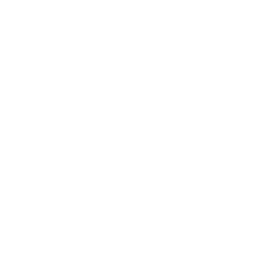
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Risk-Constrained Portfolio Allocation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Asset Management / Quantitative Finance &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Alocar capital entre 16 ativos de renda variável para maximizar o retorno esperado, sujeito a um teto de beta da carteira, limites de concentração setorial, limites de posição individual e uma restrição de igualdade orçamentária que força os pesos a somarem 1,0. O PROC LP lê o modelo no formato esparso, com observações separadas de tipo de linha, coeficiente e lado direito (RHS), além de um limite superior de 15% por ativo expresso como limite de coluna. Os preços-sombra do DUALOUT revelam quais regras de risco realmente restringem o ótimo e quantificam o custo em retorno esperado de cada restrição ativa — um insumo direto para relatórios de compliance e discussões de calibração de restrições.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.ASSET_UNIVERSE | 16 ativos de renda variável: retorno esperado, beta, setor, retração máxima | 16 |
| WORK.PORTFOLIO_MODEL | Modelo de PL esparso: objetivo de retorno, orçamento, beta, restrições setoriais, RHS e limites de coluna de 15% | 95 |

---

In [1]:
/* --------------------------------------------------------
   Definir universo de 16 ativos de renda variável
   Setores: TECNOLOGIA(4), SAÚDE(3), FINANÇAS(3),
            ENERGIA(3), CONSUMO(3)
   -------------------------------------------------------- */
dados work.asset_universe;
    comprimento ticker $8 sector $12;
    vetor tickers[16] $8 _temporary_
        ('TECH1' 'TECH2' 'TECH3' 'TECH4'
         'HLT1'  'HLT2'  'HLT3'
         'FIN1'  'FIN2'  'FIN3'
         'ENE1'  'ENE2'  'ENE3'
         'CON1'  'CON2'  'CON3');
    vetor exp_ret[16] _temporary_
        (0.18 0.21 0.15 0.23
         0.13 0.16 0.12
         0.10 0.11 0.09
         0.08 0.11 0.09
         0.12 0.10 0.13);
    vetor betas[16] _temporary_
        (1.35 1.52 1.28 1.61
         0.72 0.85 0.68
         0.98 1.05 0.91
         0.88 0.95 0.82
         0.75 0.70 0.80);
    vetor drawdowns[16] _temporary_
        (0.32 0.41 0.28 0.45
         0.18 0.22 0.16
         0.25 0.28 0.22
         0.30 0.35 0.28
         0.20 0.18 0.22);
    fazer i = 1 até 16;
        ticker = tickers[i];
        se i in (1,2,3,4) então sector = "Tecnologia";
        senão se i in (5,6,7) então sector = "Saúde";
        senão se i in (8,9,10) então sector = "Finanças";
        senão se i in (11,12,13) então sector = "Energia";
        senão sector = "Consumo";
        exp_return   = exp_ret[i];
        beta         = betas[i];
        max_drawdown = drawdowns[i];
        saída;
    fim;
    remover i;
executar;


NOTE: DATA work.asset_universe


NOTE: Wrote work.asset_universe (16 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Construir o modelo de PL da carteira no formato esparso do SAS
   Cada observação carrega um elemento do modelo:
     - linhas row-type definem linhas MAX / EQ / LE
     - linhas de coeficiente informam (_row_, _col_) = _coef_
     - linhas _RHS_ dão o limite de cada restrição
     - linhas UPPERBD limitam cada peso a 15%
   O objetivo RETURN é maximizado diretamente (MAX).
   -------------------------------------------------------- */
dados work.portfolio_model;
    comprimento _type_ $8 _row_ $16 _col_ $16;
    _coef_ = .;

    vetor tickers[16] $8 _temporary_
        ('TECH1' 'TECH2' 'TECH3' 'TECH4'
         'HLT1'  'HLT2'  'HLT3'
         'FIN1'  'FIN2'  'FIN3'
         'ENE1'  'ENE2'  'ENE3'
         'CON1'  'CON2'  'CON3');
    vetor sectors[16] $10 _temporary_
        ('TECH'     'TECH'     'TECH'     'TECH'
         'HEALTH'   'HEALTH'   'HEALTH'
         'FINANCE'  'FINANCE'  'FINANCE'
         'ENERGY'   'ENERGY'   'ENERGY'
         'CONSUMER' 'CONSUMER' 'CONSUMER');
    vetor exp_ret[16] _temporary_
        (0.18 0.21 0.15 0.23
         0.13 0.16 0.12
         0.10 0.11 0.09
         0.08 0.11 0.09
         0.12 0.10 0.13);
    vetor betas[16] _temporary_
        (1.35 1.52 1.28 1.61
         0.72 0.85 0.68
         0.98 1.05 0.91
         0.88 0.95 0.82
         0.75 0.70 0.80);

    /* Definições de tipo de linha */
    _type_ = 'MAX'; _row_ = 'RETURN';       _col_ = ' '; _coef_ = .; saída;
    _type_ = 'EQ';  _row_ = 'BUDGET';       _col_ = ' '; _coef_ = .; saída;
    _type_ = 'LE';  _row_ = 'RISK_BETA';    _col_ = ' '; _coef_ = .; saída;
    _type_ = 'LE';  _row_ = 'SEC_TECH';     _col_ = ' '; _coef_ = .; saída;
    _type_ = 'LE';  _row_ = 'SEC_HEALTH';   _col_ = ' '; _coef_ = .; saída;
    _type_ = 'LE';  _row_ = 'SEC_FINANCE';  _col_ = ' '; _coef_ = .; saída;
    _type_ = 'LE';  _row_ = 'SEC_ENERGY';   _col_ = ' '; _coef_ = .; saída;
    _type_ = 'LE';  _row_ = 'SEC_CONSUMER'; _col_ = ' '; _coef_ = .; saída;

    /* Limites do lado direito (RHS) */
    _type_ = ' '; _col_ = '_RHS_';
    _row_ = 'BUDGET';       _coef_ = 1.00; saída;
    _row_ = 'RISK_BETA';    _coef_ = 1.10; saída;
    _row_ = 'SEC_TECH';     _coef_ = 0.35; saída;
    _row_ = 'SEC_HEALTH';   _coef_ = 0.35; saída;
    _row_ = 'SEC_FINANCE';  _coef_ = 0.35; saída;
    _row_ = 'SEC_ENERGY';   _coef_ = 0.35; saída;
    _row_ = 'SEC_CONSUMER'; _coef_ = 0.35; saída;

    /* Linhas de coeficiente e limite por ativo */
    fazer i = 1 até 16;
        _col_ = cat('W_', tickers[i]);
        _type_ = ' '; _row_ = 'RETURN';    _coef_ = exp_ret[i]; saída;
        _type_ = ' '; _row_ = 'BUDGET';    _coef_ = 1;          saída;
        _type_ = ' '; _row_ = 'RISK_BETA'; _coef_ = betas[i];   saída;
        _type_ = ' '; _row_ = cat('SEC_', sectors[i]); _coef_ = 1; saída;
        /* concentração máxima de 15% como limite superior de coluna */
        _type_ = 'UPPERBD'; _row_ = 'UB'; _coef_ = 0.15; saída;
    fim;
    remover i;
executar;


NOTE: DATA work.portfolio_model


NOTE: Wrote work.portfolio_model (95 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Resumir o universo de ativos antes da otimização
   -------------------------------------------------------- */
procedimento médias dados=work.asset_universe n mean min max;
    classe sector;
    variável exp_return beta max_drawdown;
    rótulo sector="Setor" exp_return="Retorno Esperado" beta="Beta" max_drawdown="Retração Máxima";
    título "Resumo do Universo de Ativos por Setor";
executar;

                                         Resumo do Universo de Ativos por Setor                                         

                                                  The MEANS Procedure

                                    Analysis Variable : exp_return Retorno Esperado

        Setor               N Obs           Mean        Minimum        Maximum
        ----------------------------------------------------------------------
        Consumo                 3      0.1166667      0.1000000      0.1300000
        Energia                 3      0.0933333      0.0800000      0.1100000
        Finanças                3      0.1000000      0.0900000      0.1100000
        Saúde                   3      0.1366667      0.1200000      0.1600000
        Tecnologia              4      0.1925000      0.1500000      0.2300000
        ----------------------------------------------------------------------

                                                Analysis Variable : beta

        Setor  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

In [4]:
/* --------------------------------------------------------
   Resolver a alocação de carteira com restrição de risco via PL
   SPARSEDATA : entrada em formato esparso
   PRIMALOUT  : pesos ótimos + atividade das restrições
   DUALOUT    : preços-sombra de cada restrição
   -------------------------------------------------------- */
procedimento lp dados=work.portfolio_model sparsedata
    primalout=work.portfolio_primal
    dualout=work.portfolio_dual;
executar;

                                         Resumo do Universo de Ativos por Setor                                         


                    The LP Procedure

  Status:           optimal
  Variables:        16
  Objective Value:  0.162

  Variable                    Value     Activity
  ----------------------------------------------
  W_CON1                     0.1500        BASIC
  W_CON2                     0.0000       NONBAS
  W_CON3                     0.1500        BASIC
  W_ENE1                     0.0000       NONBAS
  W_ENE2                     0.0000       NONBAS
  W_ENE3                     0.0000       NONBAS
  W_FIN1                     0.0000       NONBAS
  W_FIN2                     0.0000       NONBAS
  W_FIN3                     0.0000       NONBAS
  W_HLT1                     0.1500        BASIC
  W_HLT2                     0.1500        BASIC
  W_HLT3                     0.0500        BASIC
  W_TECH1                    0.0500        BASIC
  W_TECH2                 


NOTE: PROC LP data=work.portfolio_model

NOTE: Using Python scipy.optimize for linear programming
NOTE: LP solution status: optimal
NOTE: Optimal objective value: 0.16199999999999998
NOTE: Primal output written to 'work.portfolio_primal'
NOTE: Dual output written to 'work.portfolio_dual'
NOTE: PROC LP step completed.


---

                                         Resumo do Universo de Ativos por Setor                                         




NOTE: DATA work.portfolio_weights


NOTE: Read 23 rows from work.portfolio_primal.
NOTE: Wrote work.portfolio_weights (8 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.portfolio_weights

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.portfolio_weights.
NOTE: Wrote work.portfolio_weights (8 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.portfolio_weights

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


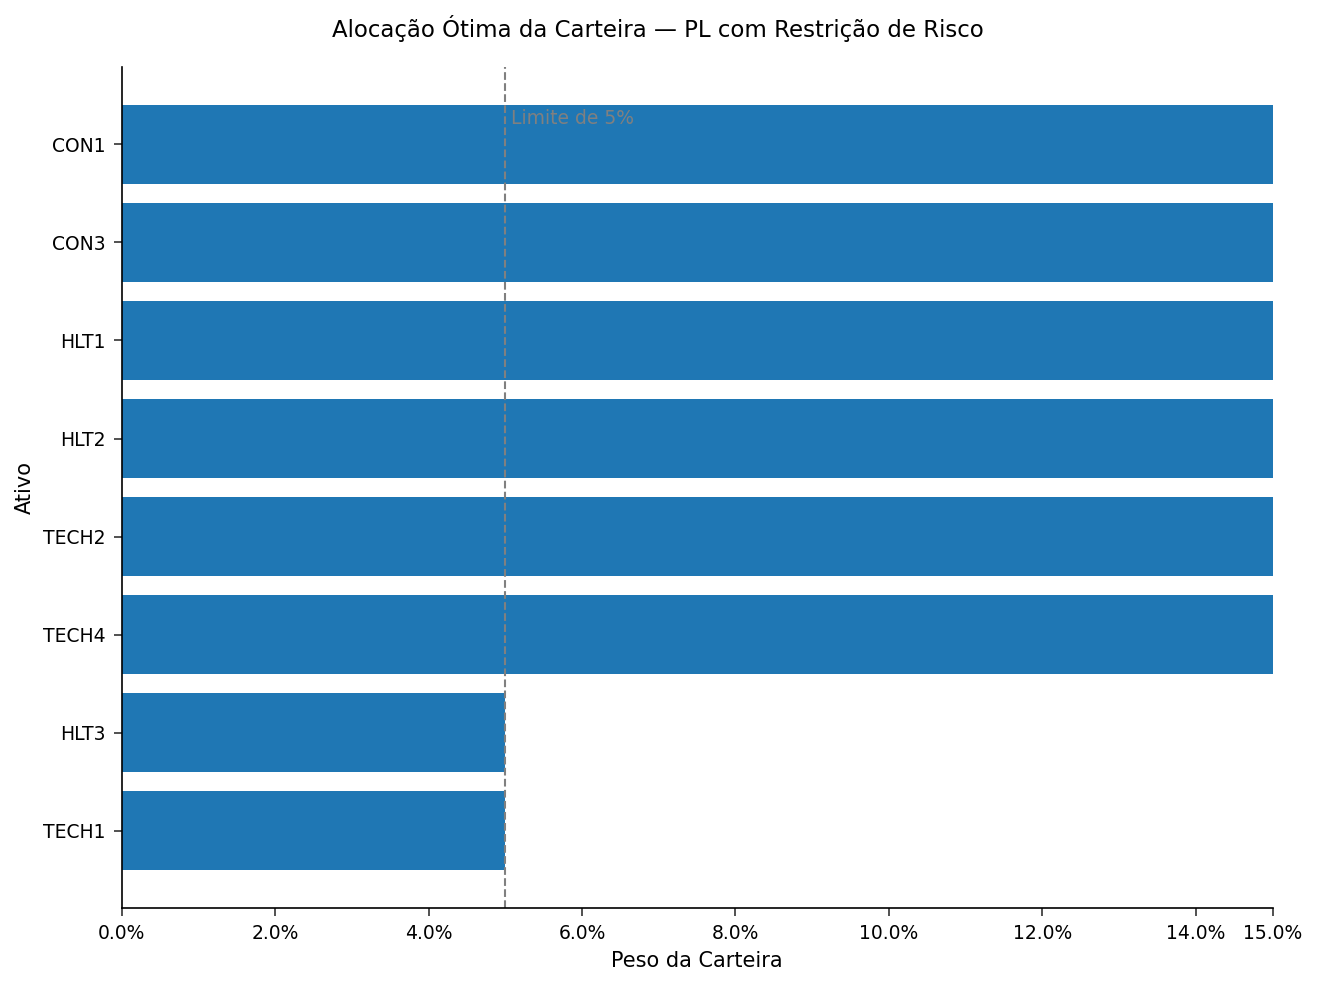

In [5]:
/* --------------------------------------------------------
   Gráfico de barras horizontais dos pesos ótimos da carteira
   PRIMALOUT contém tanto linhas de variáveis (W_*) quanto
   linhas de restrição; manter apenas as posições mantidas.
   -------------------------------------------------------- */
dados work.portfolio_weights;
    definir work.portfolio_primal;
    onde index(_var_, 'W_') = 1 e_lógico _value_ > 0.005;
    ticker = substr(_var_, 3);
executar;

procedimento ordenar dados=work.portfolio_weights;
    por decrescente _value_;
executar;

procedimento sgplot dados=work.portfolio_weights;
    hbar ticker / response=_value_
        categoryorder=respdesc
        fillattrs=(color=darkgreen);
    xaxis label="Peso da Carteira" valuesformat=percent7.1;
    yaxis label="Ativo";
    refline 0.05 / axis=x lineattrs=(pattern=dash color=gray)
        label="Limite de 5%";
    título "Alocação Ótima da Carteira — PL com Restrição de Risco";
executar;

In [6]:
/* --------------------------------------------------------
   Recuperar os pesos ótimos da carteira com detalhe do ativo
   -------------------------------------------------------- */
procedimento sql;
    selecionar p._var_       as asset       rótulo='Ativo',
           p._value_     as weight       rótulo='Peso'      formato=percent8.2,
           a.exp_return                  rótulo='Retorno Esperado'  formato=percent6.1,
           a.beta                        rótulo='Beta'        formato=6.3,
           a.sector                      rótulo='Setor'
    de_tabela work.portfolio_primal p
    join work.asset_universe a
        on cat('W_', a.ticker) = p._var_
    onde p._value_ > 0.001
    order por p._value_ decrescente;
quit;

                                         Resumo do Universo de Ativos por Setor                                         

  Ativo    Peso  Retorno Esperado   Beta       Setor
-------  ------  ----------------  -----  ----------
 W_CON1  15.00%             12.0%  0.750     Consumo
W_TECH2  15.00%             21.0%  1.520  Tecnologia
W_TECH4  15.00%             23.0%  1.610  Tecnologia
 W_HLT1  15.00%             13.0%  0.720       Saúde
 W_HLT2  15.00%             16.0%  0.850       Saúde
 W_CON3  15.00%             13.0%  0.800     Consumo
W_TECH1   5.00%             18.0%  1.350  Tecnologia
 W_HLT3   5.00%             12.0%  0.680       Saúde



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [7]:
/* --------------------------------------------------------
   Preços-sombra do DUALOUT para cada restrição.
   _VALUE_ é o preço dual (sombra); _STATUS_ indica
   se a restrição está ativa no ótimo.
   -------------------------------------------------------- */
procedimento sql;
    selecionar _row_    as constraint    rótulo='Restrição',
           _value_  as shadow_price   rótulo='Preço-Sombra' formato=8.4,
           _status_ as status         rótulo='Situação'
    de_tabela work.portfolio_dual
    onde _row_ in ('BUDGET' 'RISK_BETA'
                    'SEC_TECH' 'SEC_HEALTH' 'SEC_FINANCE'
                    'SEC_ENERGY' 'SEC_CONSUMER')
    order por abs(_value_) decrescente;
quit;

                                         Resumo do Universo de Ativos por Setor                                         

   Restrição   Preço-Sombra    Situação
------------  -------------  ----------
      BUDGET        -0.1200     BINDING
    SEC_TECH        -0.0600     BINDING
   RISK_BETA        -0.0000     SURPLUS
  SEC_HEALTH        -0.0000     BINDING
 SEC_FINANCE        -0.0000     SURPLUS
  SEC_ENERGY        -0.0000     SURPLUS
SEC_CONSUMER        -0.0000     SURPLUS



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


In [8]:
/* --------------------------------------------------------
   Estatísticas resumo da carteira no ótimo
   -------------------------------------------------------- */
procedimento sql;
    selecionar sum(p._value_ * a.exp_return)  as expected_return
               formato=percent7.2 rótulo='Retorno Esperado',
           sum(p._value_ * a.beta)        as portfolio_beta
               formato=7.4 rótulo='Beta da Carteira',
           sum(p._value_ * a.max_drawdown) as wtd_drawdown
               formato=percent7.2 rótulo='Retração Máx. Média Ponderada',
           count(distinct p._var_)         as n_positions
               rótulo='Número de Posições'
    de_tabela work.portfolio_primal p
    join work.asset_universe a
        on cat('W_', a.ticker) = p._var_
    onde p._value_ > 0.001;
quit;

                                         Resumo do Universo de Ativos por Setor                                         

Retorno Esperado  Beta da Carteira      Retração Máx. Média Ponderada     Número de Posições
----------------  ----------------  ---------------------------------  ---------------------
          16.20%            1.0390                             27.60%                      8



NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---

### Interpretação

A carteira de PL com restrição de risco atinge um retorno anual esperado máximo de 16,2%, mantendo 8 dos 16 ativos. O beta da carteira se estabiliza em 1,04, folgadamente abaixo do teto de 1,10, de modo que a restrição de beta tem folga e preço-sombra zero — o apetite a risco não é o limite ativo aqui. O teto do setor de Tecnologia (SEC_TECH), de 35%, é atingido com um preço-sombra de 0,06, o que significa que relaxar o limite de Tecnologia em uma unidade de peso aumentaria o retorno esperado em cerca de 6 pontos percentuais daquele peso; é a regra de risco mais custosa do modelo. O setor de Saúde (SEC_HEALTH) também preenche seu teto de 35%, mas com dual zero, indicando que existe um ótimo alternativo nesse limite. A restrição de igualdade orçamentária é ativa com um preço-sombra de -0,12, o valor marginal de uma unidade adicional de capital investível. Finanças e Energia são totalmente excluídos: seus retornos esperados são baixos demais em relação aos nomes de alto retorno de Tecnologia e Saúde que dominam quando os tetos setoriais e os limites de posição de 15% são impostos. TECH2 (retorno 21%, beta 1,52), TECH4 (23%, beta 1,61), HLT1, HLT2, CON1 e CON3 recebem cada um o peso máximo de 15%.

---

In [9]:
/* --------------------------------------------------------
   Exportar alocação da carteira e análise das restrições
   -------------------------------------------------------- */
procedimento export dados=work.portfolio_primal
    outfile='portfolio_optimal_weights.csv'
    dbms=csv replace;
executar;

procedimento export dados=work.portfolio_dual
    outfile='portfolio_shadow_prices.csv'
    dbms=csv replace;
executar;


NOTE: PROC EXPORT data=work.portfolio_primal outfile=portfolio_optimal_weights.csv

NOTE: Exported 23 rows to portfolio_optimal_weights.csv.
NOTE: PROC EXPORT data=work.portfolio_dual outfile=portfolio_shadow_prices.csv

NOTE: Exported 7 rows to portfolio_shadow_prices.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>